# 와인 품질 예측 모델 개발: 최적화 및 분석 보고서 (Revised)

## 1. 개요 (Overview)

### 1.1 분석 배경 및 목표
본 노트북은 와인 품질 데이터(`wine_data_homework.csv`)를 분석하여 품질 등급을 예측하는 머신러닝 모델을 개발하는 과정을 담고 있습니다.
과제의 핵심 요구사항인 **'최소한의 피처 사용'**, **'이상치 처리'**, **'MLflow를 활용한 실험 추적'**, 그리고 **'숨겨진 데이터셋에 대한 일반화 성능 확보'**를 목표로 합니다.

### 1.2 분석 전략 (Workflow)
데이터 누수(Data Leakage)를 방지하고 모델별 특성에 맞는 최적의 전처리 파이프라인을 구축합니다.

1. **데이터 분리 (Split):** 전처리 이전에 Train/Test 셋을 분리합니다.
2. **EDA & 기초 전처리:** Train 셋을 기준으로 결측치와 이상치를 분석하고 처리 전략을 수립합니다.
3. **전처리 및 피처 엔지니어링:** 
    - 스케일링과 피처 선택의 순서를 모델 특성(Tree vs Linear)에 맞춰 최적화합니다.
    - 불균형 데이터 처리는 파이프라인 내부에서 수행하여 검증 데이터 누수를 막습니다.
4. **모델링 및 MLflow:** `imblearn.pipeline`을 사용하여 전처리-샘플링-모델링 과정을 하나로 묶고 MLflow로 실험을 관리합니다.

In [1]:
# 필수 라이브러리 설치 (필요시 주석 해제)
# !pip install pandas numpy scikit-learn seaborn matplotlib mlflow imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# 불균형 데이터 처리를 위한 라이브러리
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline # sklearn Pipeline과 달리 샘플링을 지원함

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드 및 초기 분리 (Data Loading & Splitting)

### 2.1 데이터 로드 및 구조 확인

In [3]:
# 데이터 로드
df = pd.read_csv('wine_data_homework.csv')

print("데이터 크기:", df.shape)
display(df.head())
display(df.info())

데이터 크기: (4001, 13)


,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4001 non-null   int64  
 1   fixed acidity         4001 non-null   float64
 2   volatile acidity      4001 non-null   float64
 3   citric acid           4001 non-null   float64
 4   residual sugar        4001 non-null   float64
 5   chlorides             4001 non-null   float64
 6   free sulfur dioxide   4001 non-null   float64
 7   total sulfur dioxide  4001 non-null   float64
 8   density               4001 non-null   float64
 9   pH                    4001 non-null   float64
 10  sulphates             4001 non-null   float64
 11  alcohol               4001 non-null   float64
 12  quality               4001 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 406.5 KB


None


=== 기본 통계 정보 ===

=== Quality 분포 ===
quality
3      19
4     142
5    1214
6    1718
7     747
8     156
9       5
Name: count, dtype: int64

Quality 범위: 3 ~ 9


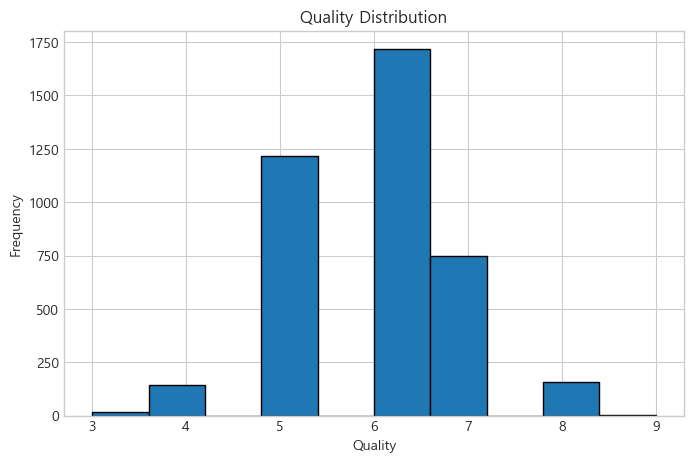

전체 데이터 크기: (4001, 12)


In [4]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    # 기본 통계 정보
print("\n=== 기본 통계 정보 ===")
df.describe()

# 타겟 변수(quality) 분포 확인
print("\n=== Quality 분포 ===")
print(df['quality'].value_counts().sort_index())
print(f"\nQuality 범위: {df['quality'].min()} ~ {df['quality'].max()}")
plt.figure(figsize=(8, 5))
df['quality'].hist(bins=10, edgecolor='black')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.title('Quality Distribution')
plt.show()

print(f"전체 데이터 크기: {df.shape}")

### 2.2 Train/Test 데이터 분리 (Stratified Split)
- **목적:** 데이터 누수(Data Leakage)를 원천 차단하기 위해 EDA 및 전처리 로직 수립 전에 데이터를 분리합니다.
- **방법:** 타겟(quality)의 비율을 유지하며 8:2로 분리합니다.

In [5]:
X = df.drop('quality', axis=1)
y = df['quality']

# Stratified Split 적용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train 데이터 크기: {X_train.shape}")
print(f"Test 데이터 크기: {X_test.shape} (최종 평가 전까지 봉인)")

Train 데이터 크기: (3200, 11)
Test 데이터 크기: (801, 11) (최종 평가 전까지 봉인)


## 3. 탐색적 데이터 분석 (EDA) - Train Set Only
**주의:** 모든 통계적 분석은 `Train Set`만을 대상으로 수행합니다.

### 3.1 결측치 및 기초 통계량 확인

In [6]:
# 결측치 확인
missing_values = X_train.isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print(f"\n총 결측치 개수: {missing_values.sum()}")
    # 결측치 시각화
    plt.figure(figsize=(10, 6))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\n결측치가 없습니다.")
    
print("Train Set 결측치 현황:")
print(missing_values[missing_values > 0])

# 기초 통계량
display(X_train.describe())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

결측치가 없습니다.
Train Set 결측치 현황:
Series([], dtype: int64)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,6.974031,0.276006,0.342163,6.349453,0.045626,35.582656,140.564687,0.994202,3.191562,0.489319,10.457312
std,0.842058,0.099775,0.123171,5.101460,0.021767,16.860769,43.481561,0.003001,0.154558,0.113699,1.216566
min,4.200000,0.080000,0.000000,0.600000,0.014000,2.000000,9.000000,0.987130,2.740000,0.220000,8.000000
25%,6.400000,0.210000,0.270000,1.700000,0.036000,23.000000,109.000000,0.991888,3.090000,0.410000,9.400000
50%,6.900000,0.260000,0.320000,5.200000,0.043000,34.000000,137.000000,0.993900,3.170000,0.470000,10.300000
75%,7.400000,0.320000,0.400000,9.700000,0.050000,47.000000,170.000000,0.996280,3.290000,0.550000,11.300000
max,14.200000,1.005000,1.660000,65.800000,0.346000,146.500000,366.500000,1.038980,3.820000,1.060000,14.000000


### 3.2 타겟(Target) 분포 확인

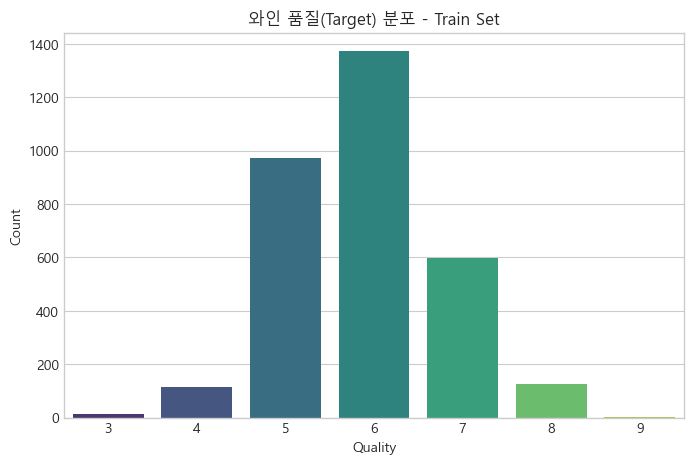

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train, palette='viridis')
plt.title('와인 품질(Target) 분포 - Train Set')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

### 3.3 피처별 분포 시각화 (Boxplot)

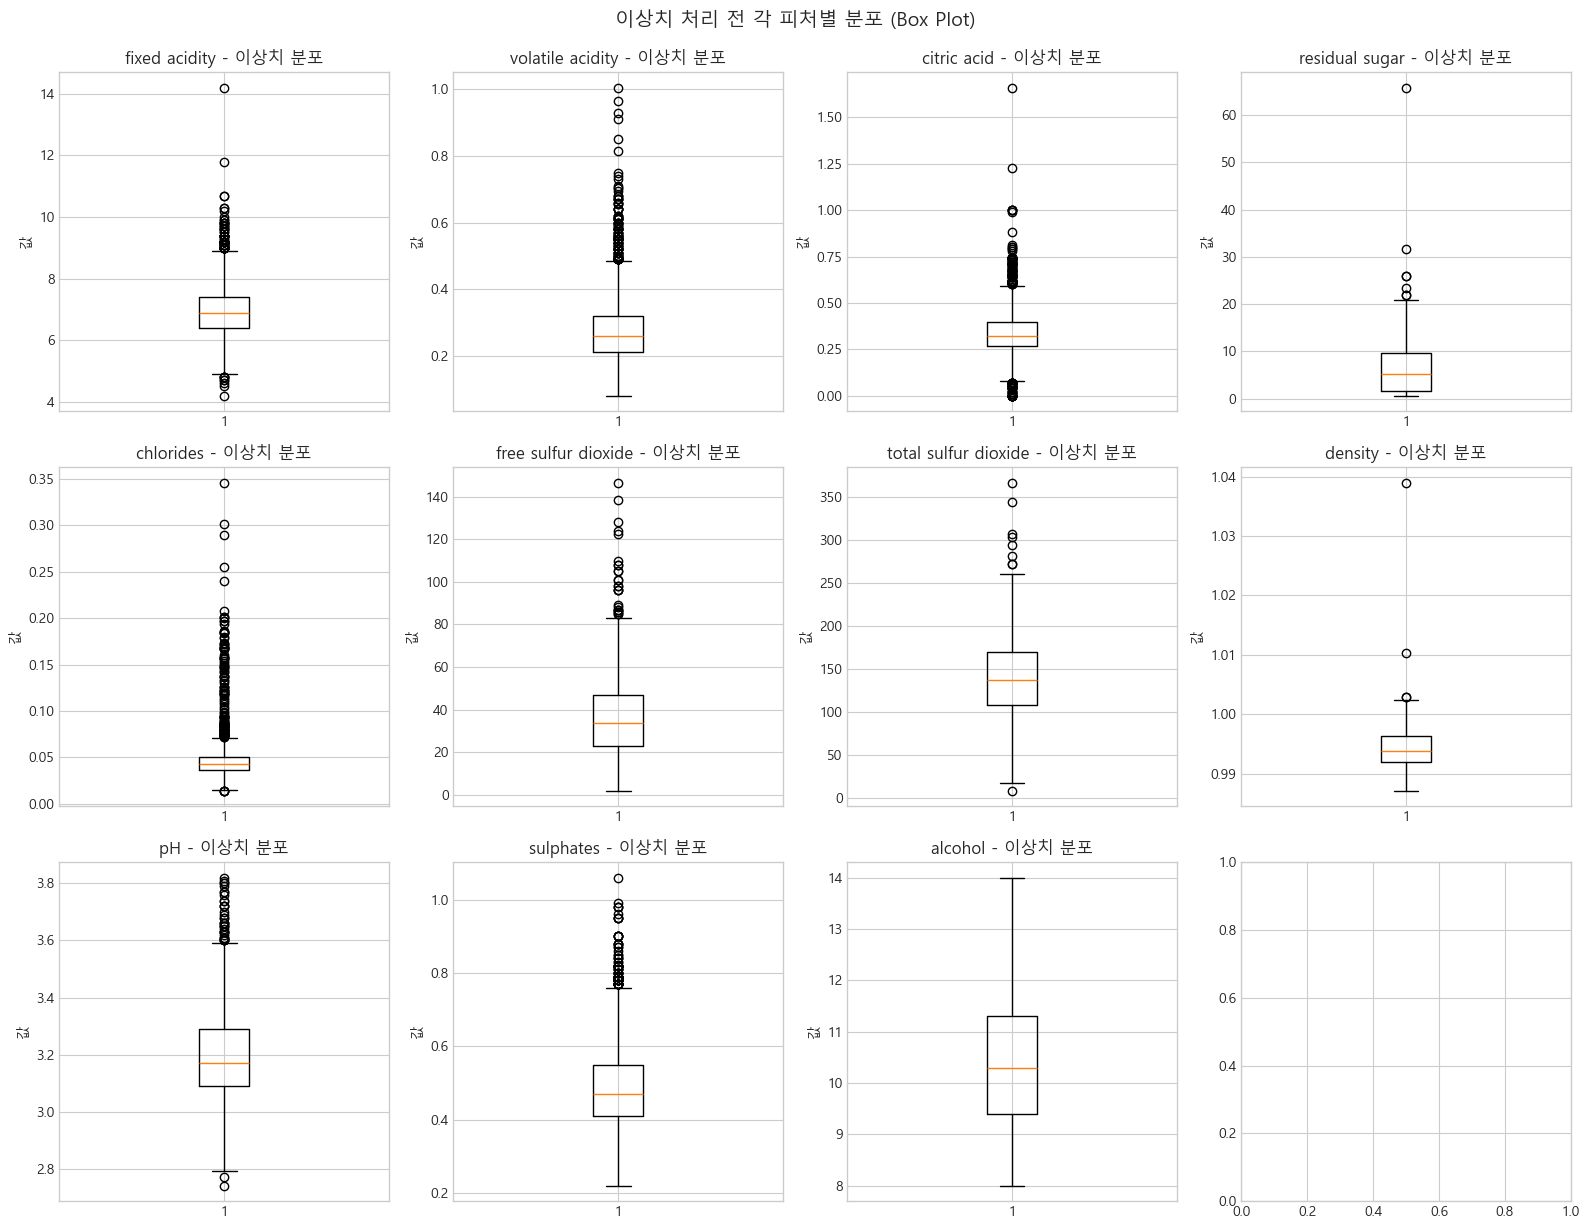

이상치로 판단되는 행 개수: 564 / 3200 (17.62%)


In [8]:
# 이상치 시각화 - Box Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    axes[idx].boxplot(X_train[col])
    axes[idx].set_title(f'{col} - 이상치 분포')
    axes[idx].set_ylabel('값')
    
plt.tight_layout()
plt.suptitle('이상치 처리 전 각 피처별 분포 (Box Plot)', y=1.02, fontsize=14)
plt.show()

# IQR 기반 이상치 개수 확인
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X_train < (Q1 - 1.5 * IQR)) | (X_train > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"이상치로 판단되는 행 개수: {outlier_mask.sum()} / {len(X_train)} ({outlier_mask.sum()/len(X_train)*100:.2f}%)")



## 4. 전처리 및 피처 엔지니어링 전략 (Preprocessing Strategy)

### 4.1 결측치 처리 (Imputation)
- 앞선 EDA에서 결측치가 없음을 확인하였으므로 별도의 대체(Imputation) 과정은 생략합니다.

### 4.2 이상치 탐지 및 제거 (Outlier Removal)
- **전략:** 데이터 손실을 최소화하기 위해 Train Set 내에서 IQR 방식을 적용하여 극단적인 이상치만 제거합니다.
- **주의:** Test Set에는 이상치 제거를 적용하지 않습니다 (현실 세계의 데이터 반영).

In [9]:
def remove_outliers_iqr(df, y, n=1.5):
    df_clean = df.copy()
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR
    lower_bound = Q1 - n * IQR
    upper_bound = Q3 + n * IQR
    
    print("=== 이상치 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===")
    outlier_info = pd.DataFrame({
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })
    print(outlier_info)

    # 모든 컬럼에 대해 이상치가 아닌 데이터만 남김 (행 기준)
    condition = ~((df < lower_bound) | (df > upper_bound)).any(axis=1)
    
    return df[condition], y[condition]

# 이상치 제거 적용 (X_train과 y_train을 합쳐서 처리 후 다시 분리)
X_train_clean, y_train_clean = remove_outliers_iqr(X_train, y_train, n=1.5)

print(f"이상치 제거 전 Train 크기: {X_train.shape}")
n_outliers = X_train.shape[0] - X_train_clean.shape[0]
print(f"이상치로 판단된 행 수(=제거된 행 수): {n_outliers}개 ({n_outliers/len(X_train)*100:.2f}%)")
print(f"이상치 제거 후 Train 크기: {X_train_clean.shape}")

=== 이상치 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar         -10.300000    21.700000
chlorides                0.015000     0.071000
free sulfur dioxide    -13.000000    83.000000
total sulfur dioxide    17.500000   261.500000
density                  0.985299     1.002869
pH                       2.790000     3.590000
sulphates                0.200000     0.760000
alcohol                  6.550000    14.150000
이상치 제거 전 Train 크기: (3200, 11)
이상치로 판단된 행 수(=제거된 행 수): 564개 (17.62%)
이상치 제거 후 Train 크기: (2636, 11)


이상치 제거 전후 데이터 분포 비교

[1] 히스토그램 비교 (전/후 오버레이)


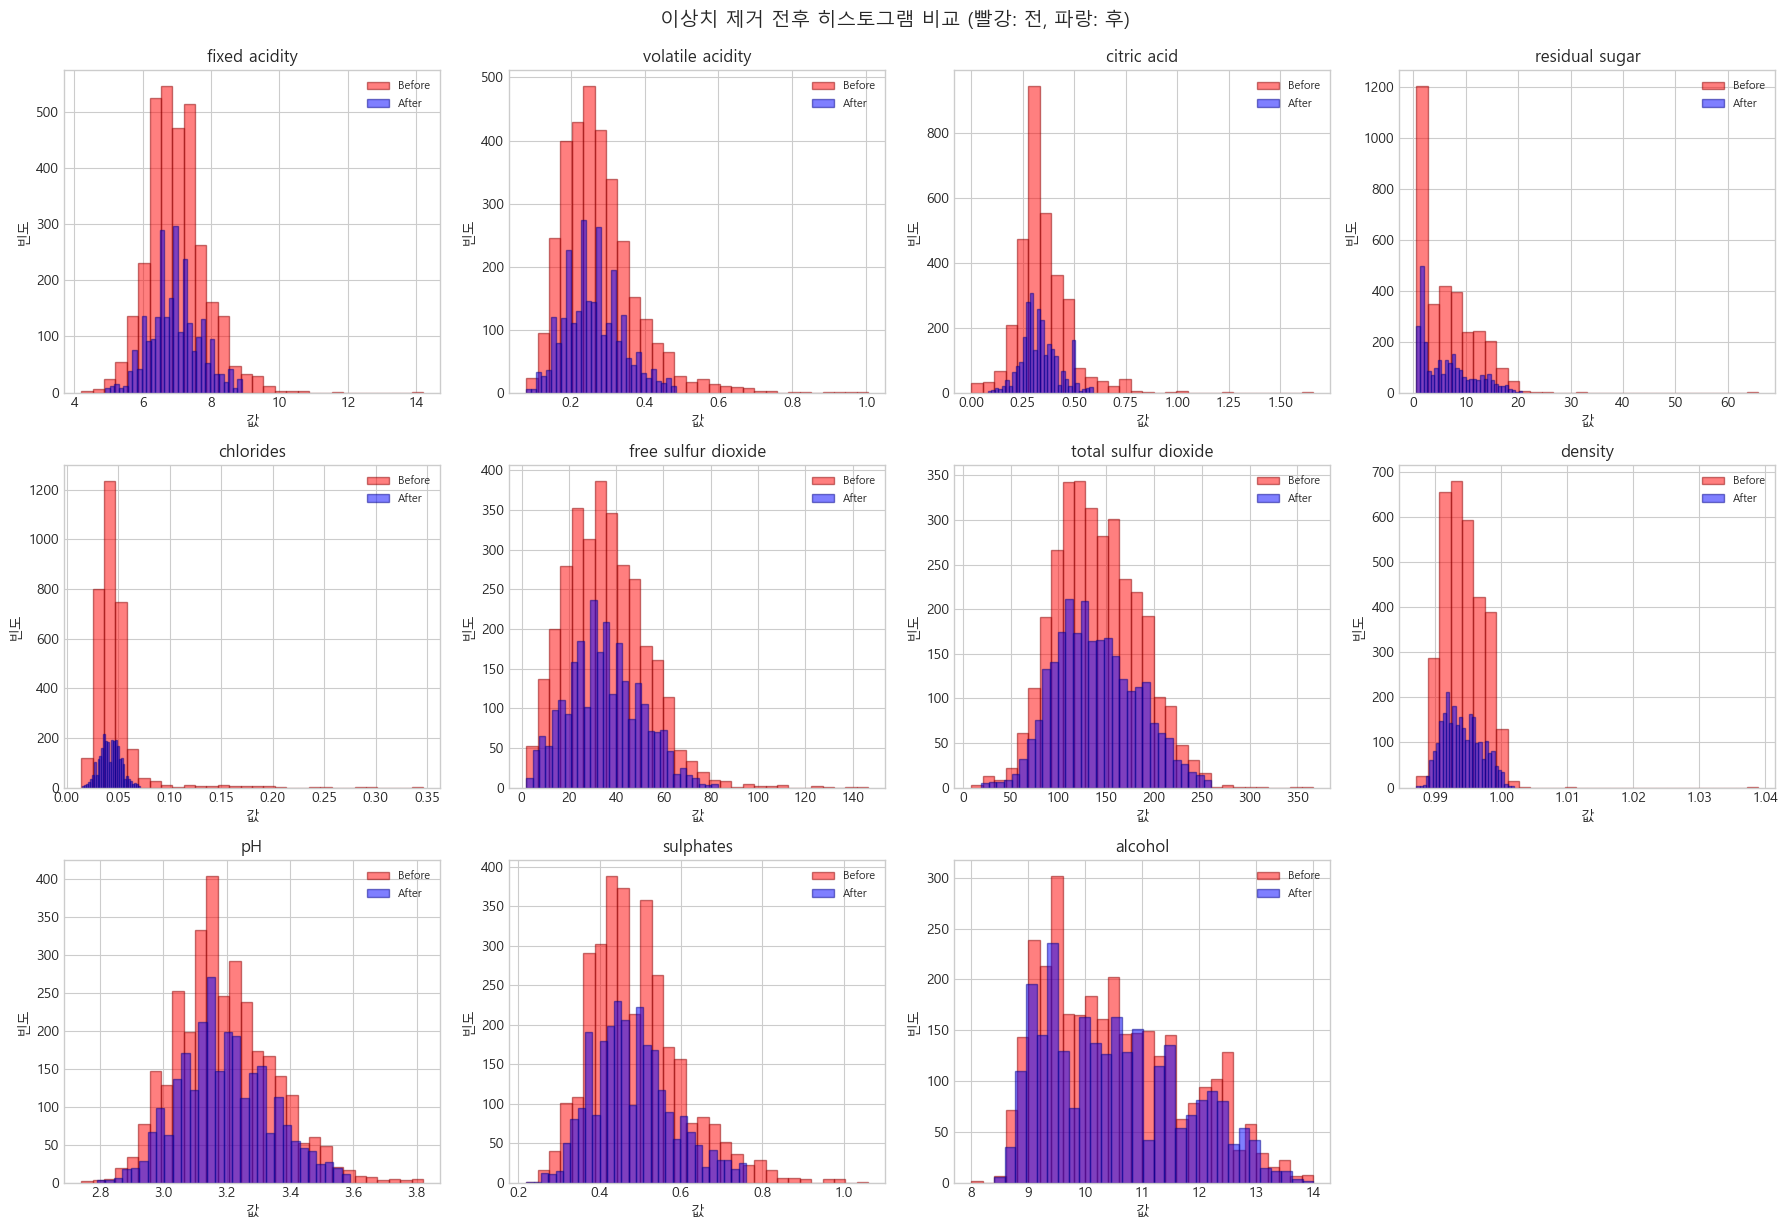


[2] 박스플롯 비교 (전/후)


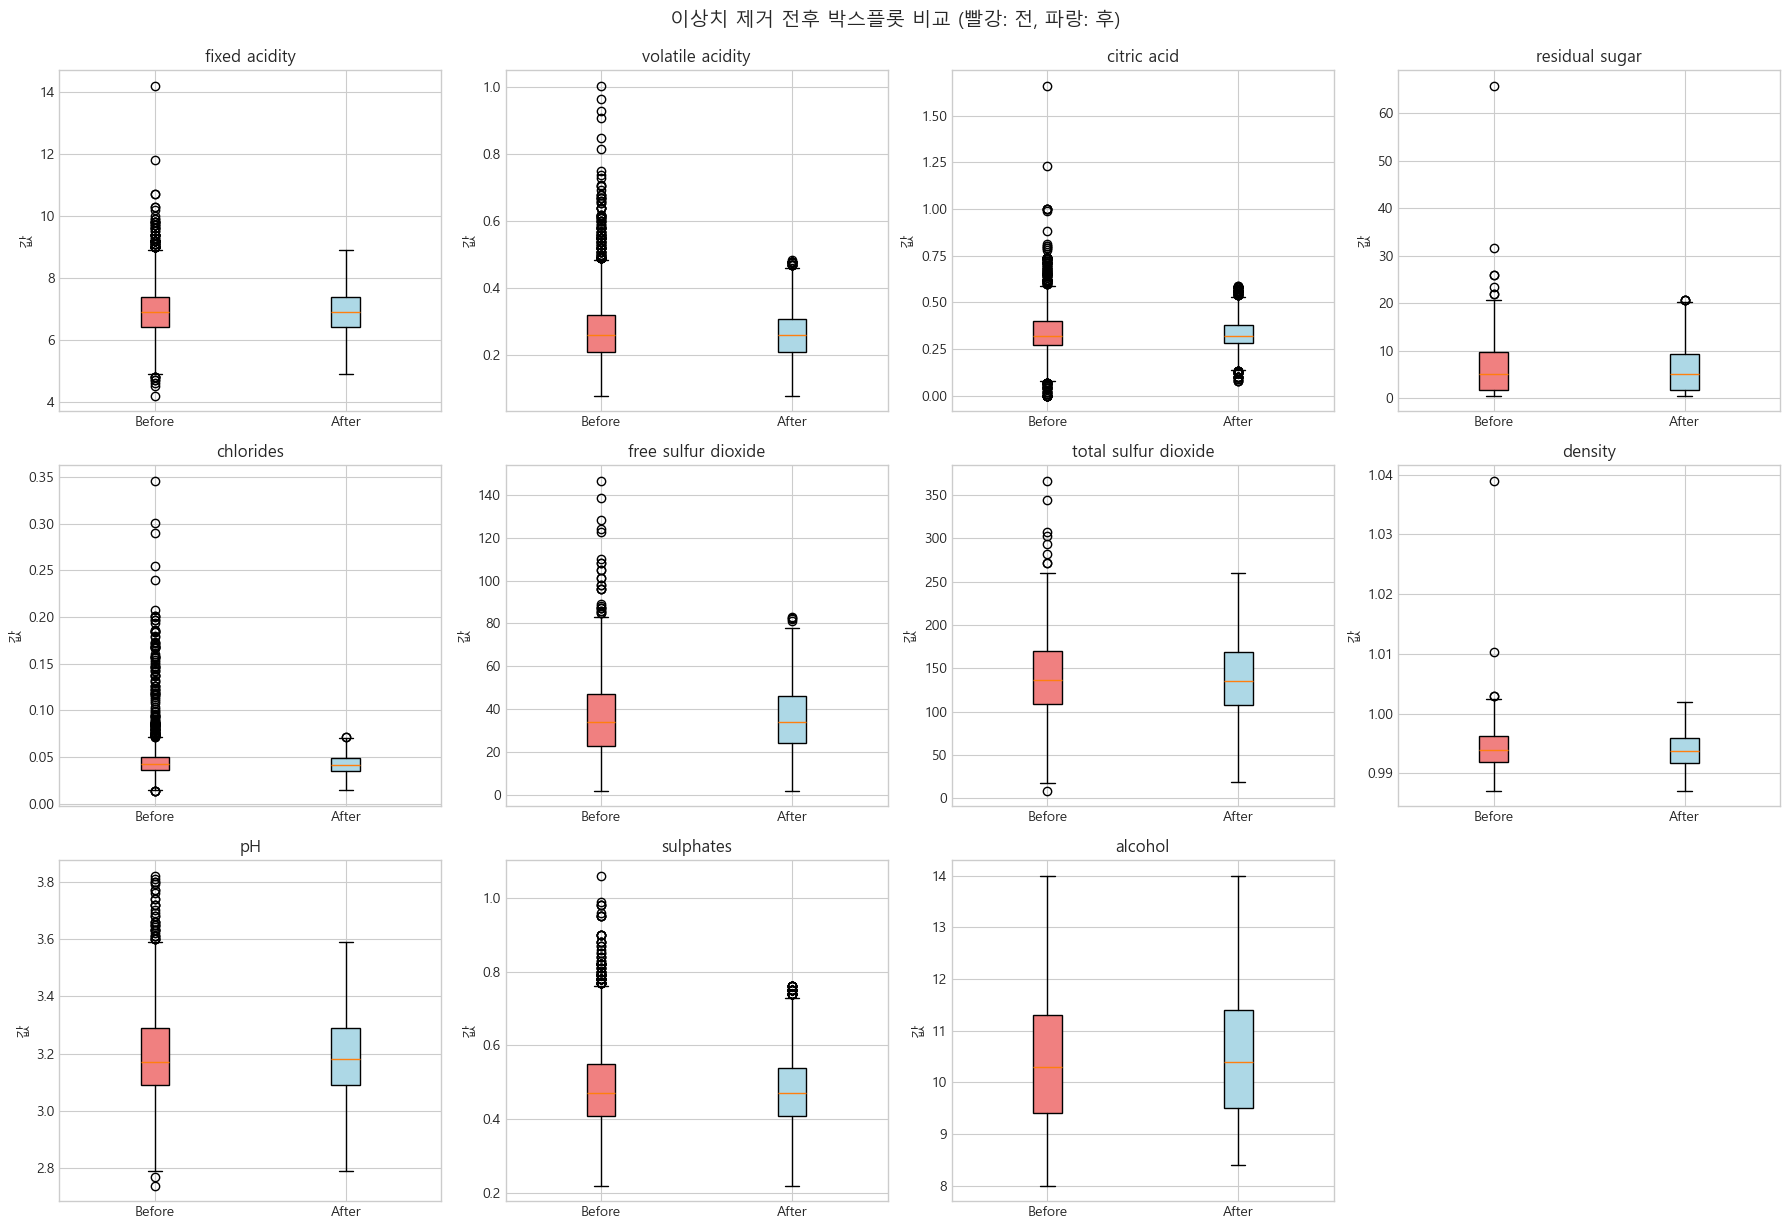


[3] 통계 요약 비교

데이터 건수 변화: 3200 → 2636 (제거: 564개, 17.62%)

=== 이상치 제거 전후 통계량 비교 ===
             Feature  Before_Mean  After_Mean  Mean_Diff  Before_Std  After_Std  Std_Diff
       fixed acidity       6.9740      6.9368    -0.0373      0.8421     0.7327   -0.1093
    volatile acidity       0.2760      0.2626    -0.0134      0.0998     0.0762   -0.0236
         citric acid       0.3422      0.3317    -0.0104      0.1232     0.0882   -0.0349
      residual sugar       6.3495      6.3027    -0.0468      5.1015     4.8990   -0.2025
           chlorides       0.0456      0.0421    -0.0036      0.0218     0.0100   -0.0118
 free sulfur dioxide      35.5827     35.0736    -0.5091     16.8608    15.2793   -1.5815
total sulfur dioxide     140.5647    139.1908    -1.3739     43.4816    42.6732   -0.8084
             density       0.9942      0.9940    -0.0002      0.0030     0.0029   -0.0001
                  pH       3.1916      3.1925     0.0009      0.1546     0.1430   -0.0116
           sulpha

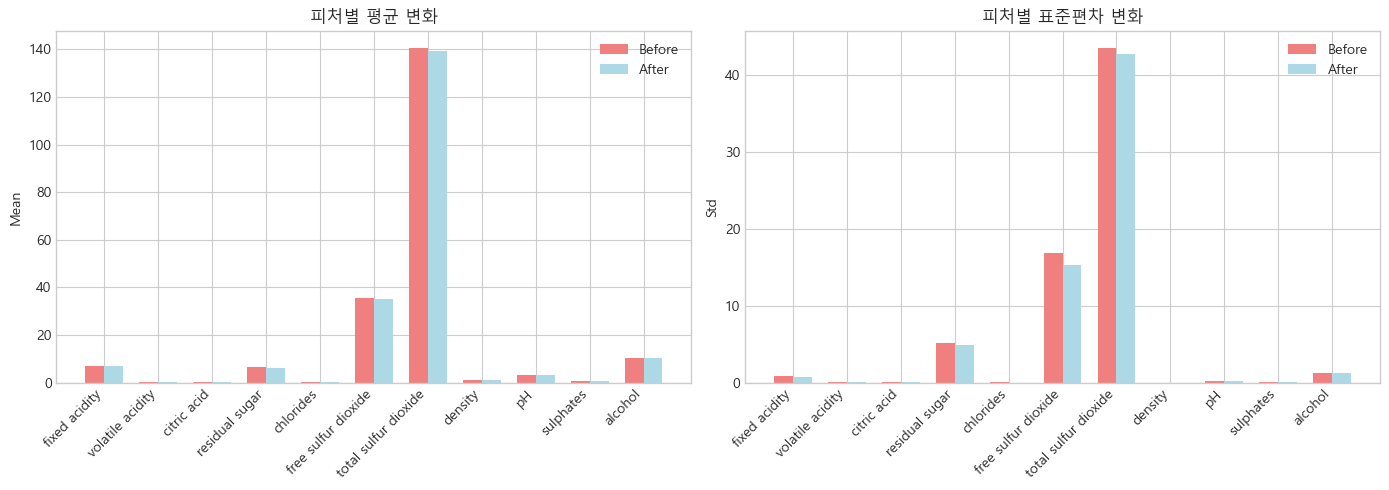


이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.


In [10]:
# ============================================
# 이상치 제거 전후 데이터 분포 비교
# ============================================
print("=" * 60)
print("이상치 제거 전후 데이터 분포 비교")
print("=" * 60)

# 1. 히스토그램 비교 (Histogram Overlay)
print("\n[1] 히스토그램 비교 (전/후 오버레이)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전: X_train (이상치 제거 전)
    ax.hist(X_train[col], bins=30, alpha=0.5, label='Before', color='red', edgecolor='darkred')
    # 후: X_train_clean (이상치 제거 후)
    ax.hist(X_train_clean[col], bins=30, alpha=0.5, label='After', color='blue', edgecolor='darkblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('값')
    ax.set_ylabel('빈도')
    ax.legend(loc='upper right', fontsize=8)

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 히스토그램 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 2. 박스플롯 비교 (Before/After Box Plot)
print("\n[2] 박스플롯 비교 (전/후)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전/후 데이터 준비
    data_before = X_train[col].values
    data_after = X_train_clean[col].values
    
    # 박스플롯 생성
    bp = ax.boxplot([data_before, data_after], labels=['Before', 'After'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
    ax.set_title(f'{col}')
    ax.set_ylabel('값')

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 박스플롯 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 3. 통계 요약 테이블 (Statistical Summary)
print("\n[3] 통계 요약 비교")
print(f"\n데이터 건수 변화: {len(X_train)} → {len(X_train_clean)} (제거: {len(X_train) - len(X_train_clean)}개, {(len(X_train) - len(X_train_clean))/len(X_train)*100:.2f}%)")

# 전후 통계량 비교 테이블
stats_comparison = []
for col in X_train.columns:
    before_stats = X_train[col].describe()
    after_stats = X_train_clean[col].describe()
    
    stats_comparison.append({
        'Feature': col,
        'Before_Mean': before_stats['mean'],
        'After_Mean': after_stats['mean'],
        'Mean_Diff': after_stats['mean'] - before_stats['mean'],
        'Before_Std': before_stats['std'],
        'After_Std': after_stats['std'],
        'Std_Diff': after_stats['std'] - before_stats['std'],
        'Before_Min': before_stats['min'],
        'After_Min': after_stats['min'],
        'Before_Max': before_stats['max'],
        'After_Max': after_stats['max']
    })

stats_df = pd.DataFrame(stats_comparison)
print("\n=== 이상치 제거 전후 통계량 비교 ===")
print(stats_df[['Feature', 'Before_Mean', 'After_Mean', 'Mean_Diff', 'Before_Std', 'After_Std', 'Std_Diff']].round(4).to_string(index=False))

print("\n=== 이상치 제거 전후 범위(Min/Max) 비교 ===")
print(stats_df[['Feature', 'Before_Min', 'After_Min', 'Before_Max', 'After_Max']].round(4).to_string(index=False))

# 4. 분포 변화 요약 시각화
print("\n[4] 평균/표준편차 변화 시각화")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 변화
ax1 = axes[0]
x = np.arange(len(stats_df))
width = 0.35
bars1 = ax1.bar(x - width/2, stats_df['Before_Mean'], width, label='Before', color='lightcoral')
bars2 = ax1.bar(x + width/2, stats_df['After_Mean'], width, label='After', color='lightblue')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax1.set_ylabel('Mean')
ax1.set_title('피처별 평균 변화')
ax1.legend()

# 표준편차 변화
ax2 = axes[1]
bars1 = ax2.bar(x - width/2, stats_df['Before_Std'], width, label='Before', color='lightcoral')
bars2 = ax2.bar(x + width/2, stats_df['After_Std'], width, label='After', color='lightblue')
ax2.set_xticks(x)
ax2.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax2.set_ylabel('Std')
ax2.set_title('피처별 표준편차 변화')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.")


### 4.3 스케일링 전략 수립 및 검증 (Scaling Strategy)
- 와인 데이터는 화학적 성분별로 단위 차이(예: Sulfur Dioxide vs Alcohol)가 큽니다.
- 이상치가 일부 존재하므로 `RobustScaler`가 이론적으로 유리할 수 있으나, 모델별로 `StandardScaler`와 비교 검증합니다.

**비교할 스케일러:**
- `Original`: 
- `StandardScaler`: 평균 0, 분산 1. 이상치에 민감.
- `MinMaxScaler`: 0~1 사이 값. 이상치에 민감.
- `RobustScaler`: 중앙값과 IQR 사용. 이상치에 강함.

**스케일링 방법별 시각적 비교**

아래 코드는 각 스케일링 방법이 데이터 분포에 미치는 영향을 시각적으로 비교합니다.


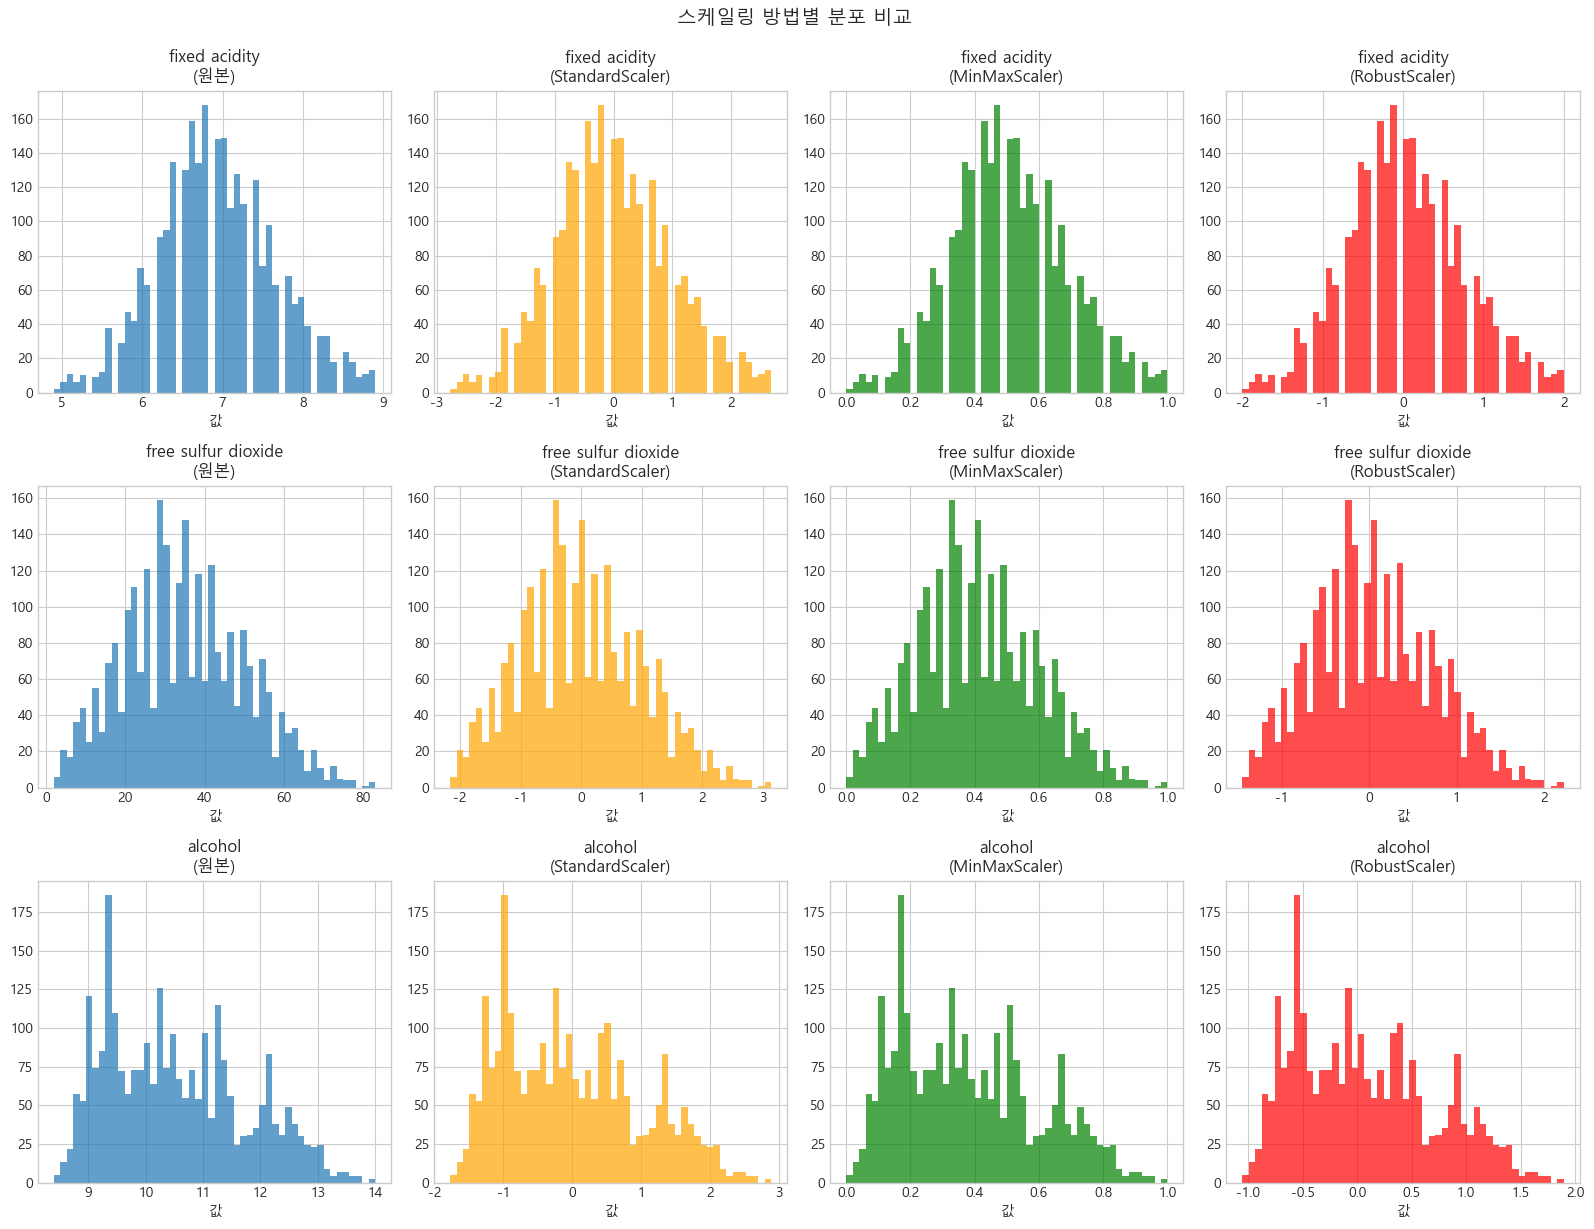

스케일링 방법별 통계량 비교 (대표 피처: fixed acidity):
                원본  StandardScaler  MinMaxScaler  RobustScaler
count  2636.000000    2.636000e+03   2636.000000   2636.000000
mean      6.936760    7.844004e-16      0.509190      0.036760
std       0.732708    1.000190e+00      0.183177      0.732708
min       4.900000   -2.780299e+00      0.000000     -2.000000
25%       6.400000   -7.327097e-01      0.375000     -0.500000
50%       6.900000   -5.017992e-02      0.500000      0.000000
75%       7.400000    6.323498e-01      0.625000      0.500000
max       8.900000    2.679939e+00      1.000000      2.000000


In [11]:
# 다양한 스케일러 적용 및 비교
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

X_train_std = scaler_std.fit_transform(X_train_clean)
X_train_minmax = scaler_minmax.fit_transform(X_train_clean)
X_train_robust = scaler_robust.fit_transform(X_train_clean)

# 시각화: 스케일링 전후 비교 (대표 피처 3개)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
feature_indices = [0, 5, 10]  # fixed acidity, total sulfur dioxide, alcohol
feature_names = [X_train_clean.columns[i] for i in feature_indices]

for row, feat_idx in enumerate(feature_indices):
    feat_name = feature_names[row]
    
    # 원본
    axes[row, 0].hist(X_train_clean.iloc[:, feat_idx], bins=50, alpha=0.7)
    axes[row, 0].set_title(f'{feat_name}\n(원본)')
    axes[row, 0].set_xlabel('값')
    
    # StandardScaler
    axes[row, 1].hist(X_train_std[:, feat_idx], bins=50, alpha=0.7, color='orange')
    axes[row, 1].set_title(f'{feat_name}\n(StandardScaler)')
    axes[row, 1].set_xlabel('값')
    
    # MinMaxScaler
    axes[row, 2].hist(X_train_minmax[:, feat_idx], bins=50, alpha=0.7, color='green')
    axes[row, 2].set_title(f'{feat_name}\n(MinMaxScaler)')
    axes[row, 2].set_xlabel('값')
    
    # RobustScaler
    axes[row, 3].hist(X_train_robust[:, feat_idx], bins=50, alpha=0.7, color='red')
    axes[row, 3].set_title(f'{feat_name}\n(RobustScaler)')
    axes[row, 3].set_xlabel('값')

plt.tight_layout()
plt.suptitle('스케일링 방법별 분포 비교', y=1.02, fontsize=14)
plt.show()

# 통계량 비교
comparison_df = pd.DataFrame({
    '원본': X_train_clean.iloc[:, 0].describe(),
    'StandardScaler': pd.Series(X_train_std[:, 0]).describe(),
    'MinMaxScaler': pd.Series(X_train_minmax[:, 0]).describe(),
    'RobustScaler': pd.Series(X_train_robust[:, 0]).describe()
})
print("스케일링 방법별 통계량 비교 (대표 피처: fixed acidity):")
print(comparison_df)


### 4.4 피처 선택 (Feature Selection)
- **중요:** 피처 선택은 모델의 특성에 따라 적용 순서가 달라질 수 있습니다.
    - **상관관계/분산 기반:** 스케일링 전 원본 데이터의 특성을 파악하는 데 유리합니다.
    - **모델 기반(Lasso 등):** 스케일링이 **먼저** 선행되어야 공정한 계수 비교가 가능합니다.

In [12]:
print(f"피처 선택을 위한 Train 데이터 크기: {X_train_clean.shape}")
print(f"Test 데이터 크기: {X_test.shape}")

피처 선택을 위한 Train 데이터 크기: (2636, 11)
Test 데이터 크기: (801, 11)


#### 4.4.1 다중공선성(VIF) 및 상관관계 분석 (사전 탐색)
- 이 단계에서는 원본 데이터(이상치 제거됨)를 사용하여 변수 간의 관계를 파악합니다.

4.4.1.1 상관관계 분석 (Correlation Analysis)

피처-타겟 상관관계 (절대값):
alcohol                 0.439080
density                 0.324982
chlorides               0.287630
total sulfur dioxide    0.158692
residual sugar          0.134187
volatile acidity        0.110840
pH                      0.099446
fixed acidity           0.071151
free sulfur dioxide     0.030537
sulphates               0.028930
citric acid             0.013784
dtype: float64

상관관계 상위 6개 피처: ['alcohol', 'density', 'chlorides', 'total sulfur dioxide', 'residual sugar', 'volatile acidity']


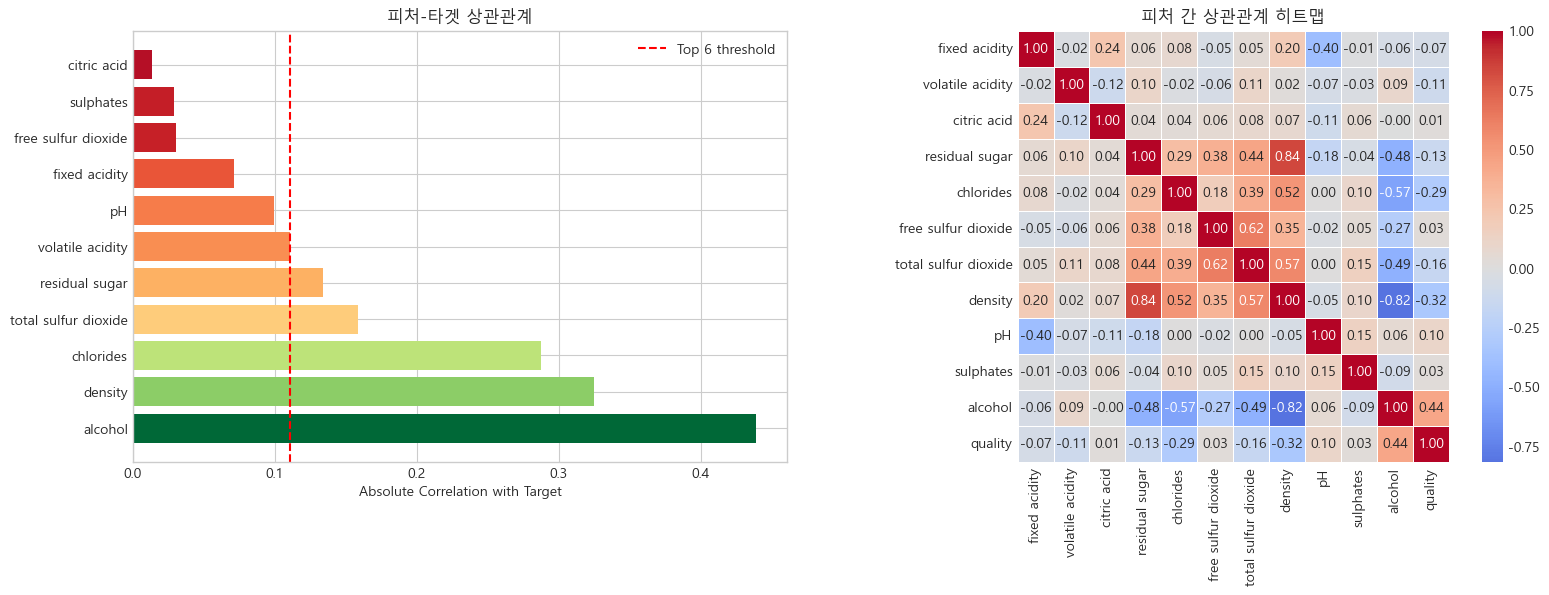

In [13]:
# ============================================
# 4.4.1.1 상관관계 분석 (Correlation Analysis)
# ============================================
print("=" * 60)
print("4.4.1.1 상관관계 분석 (Correlation Analysis)")
print("=" * 60)

# 피처-타겟 상관관계 계산
feature_target_corr = X_train_clean.apply(lambda x: x.corr(y_train_clean))
feature_target_corr = feature_target_corr.abs().sort_values(ascending=False)

print("\n피처-타겟 상관관계 (절대값):")
print(feature_target_corr)

# 상관관계 기준 상위 6개 피처 선택
n_select = 6
corr_selected = feature_target_corr.head(n_select).index.tolist()
print(f"\n상관관계 상위 {n_select}개 피처: {corr_selected}")

# 상관관계 히트맵
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 피처-타겟 상관관계
ax1 = axes[0]
colors = plt.cm.RdYlGn(feature_target_corr.values / feature_target_corr.max())
bars = ax1.barh(feature_target_corr.index, feature_target_corr.values, color=colors)
ax1.set_xlabel('Absolute Correlation with Target')
ax1.set_title('피처-타겟 상관관계')
ax1.axvline(x=feature_target_corr.iloc[n_select-1], color='red', linestyle='--', label=f'Top {n_select} threshold')
ax1.legend()

# 피처 간 상관관계 히트맵
ax2 = axes[1]
# corr_matrix = X_train_clean.corr()
corr_matrix = pd.concat([X_train_clean, y_train_clean], axis=1)
sns.heatmap(corr_matrix.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, 
            center=0, square=True, linewidths=0.5)
ax2.set_title('피처 간 상관관계 히트맵')

plt.tight_layout()
plt.show()

4.4.1.2 VIF (Variance Inflation Factor) 분석

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features        VIF
7                density  44.426408
3         residual sugar  17.711193
10               alcohol  12.006983
0          fixed acidity   2.944646
6   total sulfur dioxide   2.505068
8                     pH   2.380971
5    free sulfur dioxide   1.883875
4              chlorides   1.604882
9              sulphates   1.161774
1       volatile acidity   1.141559
2            citric acid   1.100409

VIF < 10인 피처 (8개): ['fixed acidity', 'total sulfur dioxide', 'pH', 'free sulfur dioxide', 'chlorides', 'sulphates', 'volatile acidity', 'citric acid']


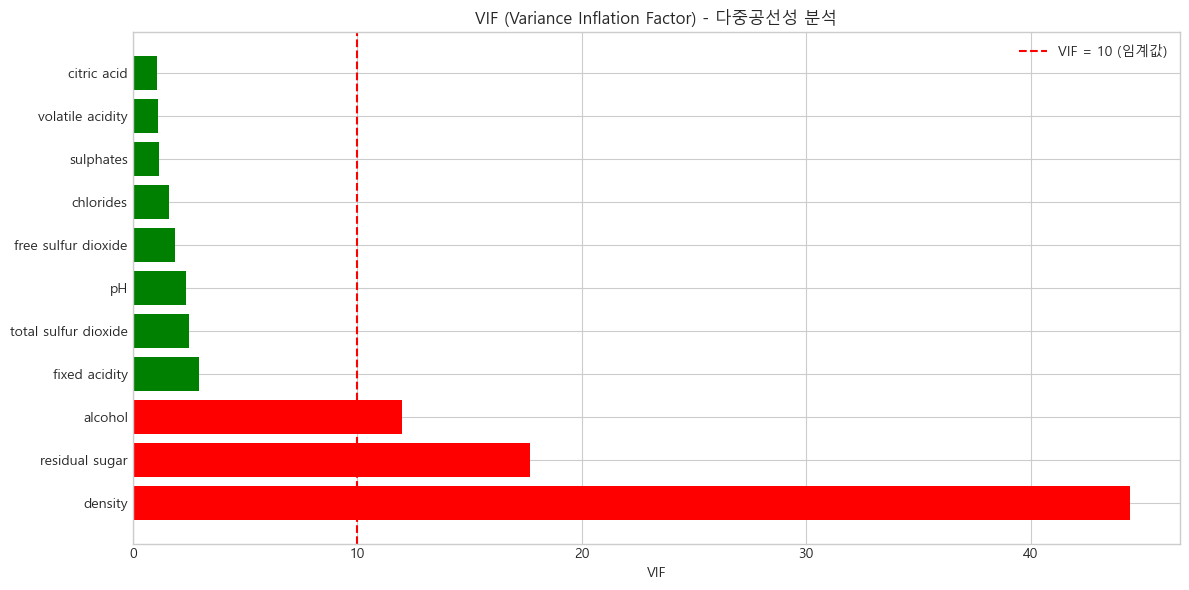

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================
# 4.4.1.2 VIF (Variance Inflation Factor) 분석
# ============================================
print("=" * 60)
print("4.4.1.2 VIF (Variance Inflation Factor) 분석")
print("=" * 60)

def calculate_vif(df):
    """VIF 계산 함수 - 다중공선성 분석"""
    vif = pd.DataFrame()
    vif["Features"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values(by="VIF", ascending=False)

# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
scaler_temp = StandardScaler()
X_scaled_temp = pd.DataFrame(
    scaler_temp.fit_transform(X_train_clean),
    columns=X_train_clean.columns
)

vif_results = calculate_vif(X_scaled_temp)
print("\nVIF 분석 결과 (VIF > 10: 다중공선성 의심):")
print(vif_results)

# VIF 기준 피처 선택 (VIF < 10인 피처)
vif_selected = vif_results[vif_results['VIF'] < 10]['Features'].tolist()
print(f"\nVIF < 10인 피처 ({len(vif_selected)}개): {vif_selected}")

# VIF 시각화
plt.figure(figsize=(12, 6))
colors = ['red' if v > 10 else 'green' for v in vif_results['VIF']]
plt.barh(vif_results['Features'], vif_results['VIF'], color=colors)
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10 (임계값)')
plt.xlabel('VIF')
plt.title('VIF (Variance Inflation Factor) - 다중공선성 분석')
plt.legend()
plt.tight_layout()
plt.show()

### 4.5 불균형 데이터 처리 (Imbalanced Data Handling)
- 타겟 분포 확인 결과 클래스 불균형이 존재합니다.
- **전략:** `SMOTETomek`을 사용하여 오버샘플링과 언더샘플링을 결합합니다.
- **위치 선정:** **반드시 파이프라인 내부**에서 수행해야 합니다. (Feature Selection 이후, Modeling 직전 권장)

## 5. 모델링 및 하이퍼파라미터 튜닝 (Modeling with MLflow)

### 5.1 최종 파이프라인 구축 (Pipeline Construction)
**전문가 검토 반영:** 모델 유형에 따라 파이프라인 순서를 차별화합니다.

1. **Tree-based (Random Forest, XGBoost):** 
    - 스케일링 영향이 적음 -> **[Feature Selection] -> [Scaling (Optional)] -> [Sampling] -> [Model]**
    - *본 실험에서는 Tree 모델에 대해 Mutual Info 기반 선택을 적용합니다.*
2. **Linear-based (Logistic Regression, SVM):** 
    - 스케일 민감 -> **[Scaling] -> [Feature Selection] -> [Sampling] -> [Model]**
    - *Linear 모델은 ANOVA F-value 기반 선택을 적용합니다.*

In [18]:
# MLflow 실험 설정
mlflow.set_experiment("Wine_Quality_Optimization_Revised")

# Minority class 샘플 수가 극단적으로 적어서, k_neighbors를 1로 설정 (최소한의 이웃만 사용)
smote_tomek = SMOTETomek(
    random_state=42,
    smote=SMOTE(k_neighbors=1, random_state=42)
)

# 1. Logistic Regression Pipeline (Scaling -> Selection -> Sampling -> Model)
pipe_lr = ImbPipeline([
    ('scaler', RobustScaler()),                   # 1. 스케일링 (선형 모델 필수)
    ('selector', SelectKBest(f_classif, k=6)),    # 2. 피처 선택 (ANOVA)
    ('sampler', smote_tomek),     # 3. 샘플링 (불균형 처리)
    ('clf', LogisticRegression(max_iter=1000, random_state=42)) # 4. 모델
])

# 2. Random Forest Pipeline (Selection -> Sampling -> Model)
# 트리 모델은 스케일링이 필수는 아니지만, 파이프라인 통일성을 위해 포함하거나 생략 가능
pipe_rf = ImbPipeline([
    ('scaler', 'passthrough'),                    # 트리 모델은 스케일링 생략 가능 (passthrough)
    ('selector', SelectKBest(mutual_info_classif, k=6)), # 1. 피처 선택 (Mutual Info: 비선형 관계 포착)
    ('sampler', smote_tomek),     # 2. 샘플링
    ('clf', RandomForestClassifier(random_state=42)) # 3. 모델
])

### 5.2 모델별 하이퍼파라미터 그리드 설계

In [19]:
param_grid_lr = {
    'scaler': [StandardScaler(), RobustScaler()],   # 스케일러 비교
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['lbfgs', 'liblinear']
}

param_grid_rf = {
    'selector__k': [5, 6, 7],                       # 최적 피처 개수 탐색
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

### 5.3 GridSearchCV 및 MLflow 실험 실행

In [20]:
def run_experiment(pipeline, param_grid, model_name):
    with mlflow.start_run(run_name=model_name):
        # Grid Search
        grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
        grid.fit(X_train_clean, y_train_clean)
        
        # Best Model & Params
        best_model = grid.best_estimator_
        print(f"[{model_name}] Best Params: {grid.best_params_}")
        print(f"[{model_name}] Best CV Score: {grid.best_score_:.4f}")
        
        # Logging to MLflow
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("best_cv_f1", grid.best_score_)
        mlflow.sklearn.log_model(best_model, model_name)
        
        return best_model

# 실험 실행
print("Running Logistic Regression Experiment...")
best_lr = run_experiment(pipe_lr, param_grid_lr, "Logistic_Regression")

print("\nRunning Random Forest Experiment...")
best_rf = run_experiment(pipe_rf, param_grid_rf, "Random_Forest")

Running Logistic Regression Experiment...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


2025/11/27 15:30:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Logistic_Regression] Best Params: {'clf__C': 1, 'clf__solver': 'lbfgs', 'scaler': RobustScaler()}
[Logistic_Regression] Best CV Score: 0.3452


2025/11/27 15:30:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Running Random Forest Experiment...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


2025/11/27 15:33:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Random_Forest] Best Params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200, 'selector__k': 7}
[Random_Forest] Best CV Score: 0.6025


2025/11/27 15:33:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 6. 최종 모델 성능 평가 (Final Evaluation)

### 6.1 최종 모델 선정 및 Test Set 평가
- CV 성능이 더 우수한 모델을 최종 모델로 선정하여 Test Set에 대한 일반화 성능을 평가합니다.

In [21]:
# 예시: Random Forest가 더 좋다고 가정 (실제로는 score 비교 필요)
final_model = best_rf

# Test Set 평가
y_pred = final_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("Final Test F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Final Test Accuracy: 0.5780274656679151
Final Test F1 Score: 0.5721908371277328


### 6.2 오차 행렬(Confusion Matrix) 및 분류 보고서

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.31      0.18      0.23        28
           5       0.58      0.67      0.62       243
           6       0.61      0.52      0.56       344
           7       0.56      0.67      0.61       150
           8       0.47      0.52      0.49        31
           9       0.00      0.00      0.00         1

    accuracy                           0.58       801
   macro avg       0.36      0.36      0.36       801
weighted avg       0.57      0.58      0.57       801



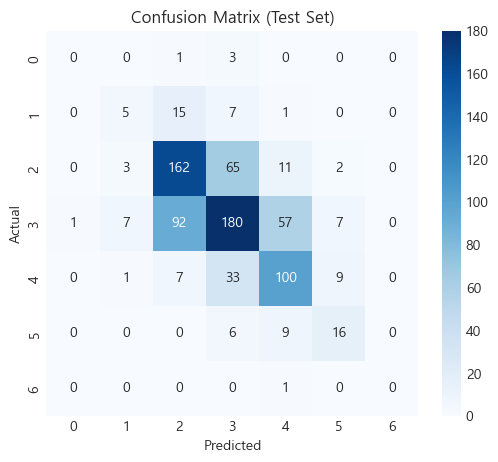

In [22]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 6.3 피처 중요도(Feature Importance) 시각화
- Pipeline 내부 단계(Step) 이름에 유의하여 Feature Importance를 추출합니다.

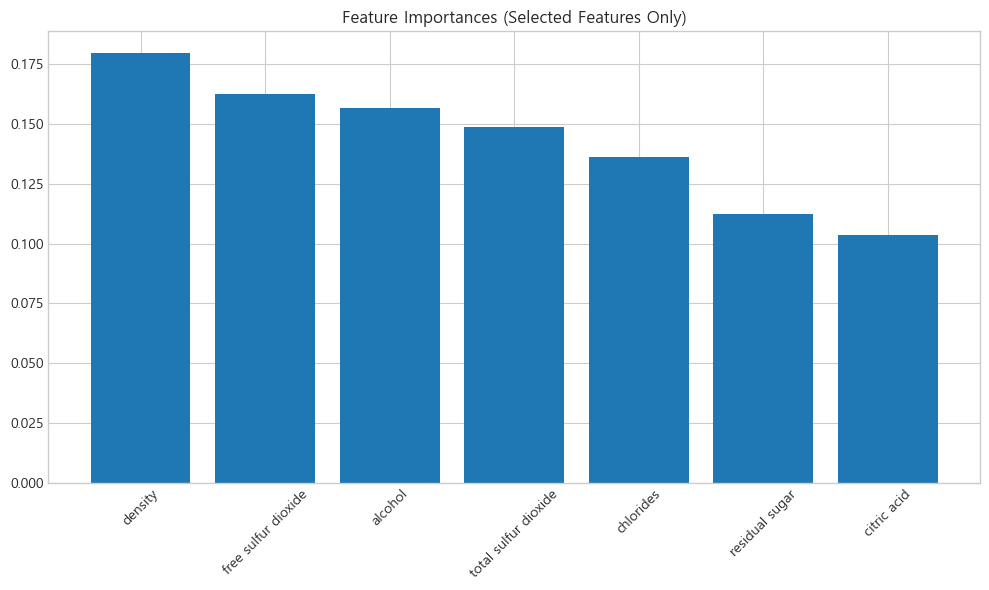

In [23]:
# Random Forest의 Feature Importance 추출
# 파이프라인 단계: [scaler] -> [selector] -> [sampler] -> [clf]
# 주의: SelectKBest로 피처가 줄어들었으므로, 선택된 피처의 이름을 추적해야 함

selector = final_model.named_steps['selector']
clf = final_model.named_steps['clf']

# 선택된 피처의 마스크 가져오기
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]

# 중요도 매핑
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Selected Features Only)')
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), selected_features[indices], rotation=45)
plt.tight_layout()
plt.show()

## 7. 결론 및 제언 (Conclusion)
- 실험 결과 요약
- 모델의 강점과 한계점 분석
- 향후 개선 방향